In [ ]:
# 1. Mount Google Drive
from google.colab import drive
import os

drive.mount('/content/drive')

# 2. Define and create project directories
PROJECT_PATH = '/content/drive/MyDrive/Parasite_Project'
os.makedirs(PROJECT_PATH, exist_ok=True)
os.makedirs(f"{PROJECT_PATH}/checkpoints", exist_ok=True)
os.makedirs(f"{PROJECT_PATH}/data", exist_ok=True)

print(f"Project directory successfully established at: {PROJECT_PATH}")

Mounted at /content/drive
Project directory successfully established at: /content/drive/MyDrive/Parasite_Project


In [ ]:
import zipfile
import pandas as pd
import numpy as np
import glob
import os

# Unzip the dataset directly inside Google Drive (Permanent Storage)
ZIP_FILE_PATH = f"{PROJECT_PATH}/data/parasite-dataset.zip"
EXTRACT_PATH = f"{PROJECT_PATH}/data/parasite_dataset_unzipped"

if not os.path.exists(EXTRACT_PATH):
    print("Extracting dataset directly to Google Drive... Please wait...")
    with zipfile.ZipFile(ZIP_FILE_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print(f"Dataset extracted successfully to: {EXTRACT_PATH}")
else:
    print(f"Dataset already extracted at: {EXTRACT_PATH}")

Extracting dataset directly to Google Drive... Please wait...
Dataset extracted successfully to: /content/drive/MyDrive/Parasite_Project/data/parasite_dataset_unzipped


In [ ]:
# Dynamic generation of medical indicators for all 8 classes
all_images = glob.glob(f"{EXTRACT_PATH}/**/*.png", recursive=True) + glob.glob(f"{EXTRACT_PATH}/**/*.jpg", recursive=True)

np.random.seed(42)
metadata_list = []

for img_path in all_images:
    # Extract class label from the parent directory name
    label_name = os.path.basename(os.path.dirname(img_path)).lower()

    # Advanced conditional logic to support the 4 core classes + 4 new/other classes dynamically
    if "malaria" in label_name:
        temp = np.random.uniform(38.5, 40.5)      # High periodic fever
        hb = np.random.uniform(7.0, 10.5)         # Severe Anemia
        wbc = np.random.uniform(4000, 10000)      # Normal/Low WBC
        chills = 1                                # High chills

    elif "babesia" in label_name:
        temp = np.random.uniform(38.0, 39.8)      # Moderate to high fever
        hb = np.random.uniform(8.5, 11.5)         # Moderate Anemia
        wbc = np.random.uniform(5000, 12000)      # Fluctuation in WBC
        chills = np.random.choice([0, 1], p=[0.3, 0.7])

    elif "leishmania" in label_name:
        temp = np.random.uniform(37.5, 39.0)      # Low-grade persistent fever
        hb = np.random.uniform(8.0, 11.0)         # Chronic Anemia
        wbc = np.random.uniform(11000, 16000)     # Very High WBC (Immune response)
        chills = 0

    elif "normal" in label_name:
        temp = np.random.uniform(36.5, 37.3)      # Normal baseline
        hb = np.random.uniform(12.5, 16.0)        # Healthy Hemoglobin
        wbc = np.random.uniform(4500, 11000)      # Standard WBC
        chills = 0

    else:
        # Dynamic simulation for the remaining 4 classes based on general parasitic infections
        # This acts as a robust baseline for any other specific parasite in your 8 classes
        temp = np.random.uniform(37.2, 38.8)      # Mild infection fever
        hb = np.random.uniform(9.5, 12.5)         # Mild/Moderate blood loss
        wbc = np.random.uniform(9000, 14000)      # Elevated white cells to fight infection
        chills = np.random.choice([0, 1], p=[0.6, 0.4])

    metadata_list.append({
        "image_path": img_path,
        "label_name": label_name.capitalize(),    # Standardize names
        "temperature": temp,
        "hemoglobin": hb,
        "wbc_count": wbc,
        "chills": chills
    })

# Construct DataFrame and automatically encode all 8 unique classes
df = pd.DataFrame(metadata_list)
df['label'] = df['label_name'].astype('category').cat.codes

# Print class mapping configuration to verify all 8 classes are captured perfectly
print("\n--- Detected Class Mapping (Total 8 Classes) ---")
mapping = dict(enumerate(df['label_name'].astype('category').cat.categories))
for code, name in mapping.items():
    print(f"Class Code {code} -> Disease/Class Name: {name}")

# Save the master metadata CSV securely on Google Drive
CSV_PATH = f"{PROJECT_PATH}/data/clinical_metadata.csv"
df.to_csv(CSV_PATH, index=False)
print(f"\nClinical metadata successfully saved to Drive. Total dataset size: {len(df)} entries.")


--- Detected Class Mapping (Total 8 Classes) ---
Class Code 0 -> Disease/Class Name: Babesia
Class Code 1 -> Disease/Class Name: Leishmania
Class Code 2 -> Disease/Class Name: Leukocyte
Class Code 3 -> Disease/Class Name: Plasmodium
Class Code 4 -> Disease/Class Name: Rbcs
Class Code 5 -> Disease/Class Name: Toxoplasma
Class Code 6 -> Disease/Class Name: Trichomonad
Class Code 7 -> Disease/Class Name: Trypanosome

Clinical metadata successfully saved to Drive. Total dataset size: 34298 entries.


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torchvision.transforms as transforms

# Load metadata and apply standard scaling to continuous numerical features
df = pd.read_csv(CSV_PATH)
X_clinical = df[['temperature', 'hemoglobin', 'wbc_count', 'chills']].values
scaler = StandardScaler()
X_clinical_scaled = scaler.fit_transform(X_clinical)

# Stratified Train-Test split (80% Train, 20% Test)
train_df, test_df, train_clin, test_clin = train_test_split(
    df, X_clinical_scaled, test_size=0.2, random_state=42, stratify=df['label']
)

# Image preprocessing pipeline (Standard ResNet)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class MultimodalDataset(Dataset):
    def __init__(self, dataframe, clinical_data, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.clinical_data = clinical_data
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'image_path']
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.loc[idx, 'label'])
        clinical = torch.tensor(self.clinical_data[idx], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, clinical, label

train_dataset = MultimodalDataset(train_df, train_clin, transform=transform)
test_dataset = MultimodalDataset(test_df, test_clin, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [ ]:
import torch.nn as nn
from torchvision.models import resnet34, ResNet34_Weights

class ParasiteMultimodalModel(nn.Module):
    def __init__(self, num_classes, clinical_dim):
        super().__init__()
        # 1. Image Processing Branch (Pre-trained ResNet34)
        self.image_model = resnet34(weights=ResNet34_Weights.DEFAULT)
        img_features_dim = self.image_model.fc.in_features
        self.image_model.fc = nn.Identity() # Remove the final layer to extract raw features

        # 2. Clinical Data Branch (Multi-Layer Perceptron)
        self.clinical_model = nn.Sequential(
            nn.Linear(clinical_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # 3. Fusion Layer and Classification Head
        self.classifier = nn.Sequential(
            nn.Linear(img_features_dim + 32, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, image, clinical):
        img_feats = self.image_model(image)
        clin_feats = self.clinical_model(clinical)

        # Concatenate features from both input modalities
        combined = torch.cat((img_feats, clin_feats), dim=1)
        logits = self.classifier(combined)
        return logits

num_classes = len(df['label'].unique())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ParasiteMultimodalModel(num_classes=num_classes, clinical_dim=4).to(device)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 130MB/s]


No existing checkpoint found. Starting fresh training session.

--- Training Started ---


Epoch 1/15:   0%|          | 0/1715 [00:00<?, ?batch/s]

=> Epoch 1 Completed - Average Loss: 0.0464
--- New best model checkpoint saved at Google Drive! (Loss: 0.0464) ---



Epoch 2/15:   0%|          | 0/1715 [00:00<?, ?batch/s]

=> Epoch 2 Completed - Average Loss: 0.0257
--- New best model checkpoint saved at Google Drive! (Loss: 0.0257) ---



...

=> Epoch 13 Completed - Average Loss: 0.0047
--- New best model checkpoint saved at Google Drive! (Loss: 0.0047) ---



Epoch 14/15:   0%|          | 0/1715 [00:00<?, ?batch/s]

=> Epoch 14 Completed - Average Loss: 0.0075
--- No improvement in this epoch. Checkpoint not updated. ---



Epoch 15/15:   0%|          | 0/1715 [00:00<?, ?batch/s]

=> Epoch 15 Completed - Average Loss: 0.0070
--- No improvement in this epoch. Checkpoint not updated. ---

Training cycle complete! The optimal weights are secure on Google Drive.


In [ ]:
# 1. Mount Drive again
from google.colab import drive
import os
drive.mount('/content/drive')

# 2. Re-define the lost paths
PROJECT_PATH = '/content/drive/MyDrive/Parasite_Project'
CSV_PATH = f"{PROJECT_PATH}/data/clinical_metadata.csv"

Mounted at /content/drive


In [ ]:
!pip install --upgrade sympy

In [ ]:
!pip install --upgrade sympy torchvision torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.5/201.5 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 90.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 

In [ ]:
import sympy
import sympy.printing
# Now your existing imports...
import os
import torch
import torch.nn as nn
from torchvision.models import resnet34, ResNet34_Weights
# baki sob code ekhon hoboho thakbe...

In [ ]:
import os
import torch
import torch.nn as nn
from torchvision.models import resnet34, ResNet34_Weights
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Environment & Path Configuration
from google.colab import drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

PROJECT_PATH = '/content/drive/MyDrive/Parasite_Project'
CSV_PATH = f"{PROJECT_PATH}/data/clinical_metadata.csv"
CHECKPOINT_PATH = f"{PROJECT_PATH}/checkpoints/best_multimodal_model.pth"

if not os.path.exists(CSV_PATH) or not os.path.exists(CHECKPOINT_PATH):
    raise FileNotFoundError("Required metadata or model checkpoint missing in Google Drive!")

# Re-define Model Architecture
class ParasiteMultimodalModel(nn.Module):
    def __init__(self, num_classes, clinical_dim):
        super().__init__()
        # Image Processing Branch (Pre-trained ResNet34)
        self.image_model = resnet34(weights=ResNet34_Weights.DEFAULT)
        img_features_dim = self.image_model.fc.in_features
        self.image_model.fc = nn.Identity()

        # Clinical Data Branch (Multi-Layer Perceptron)
        self.clinical_model = nn.Sequential(
            nn.Linear(clinical_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # Fusion Layer and Classification Head
        self.classifier = nn.Sequential(
            nn.Linear(img_features_dim + 32, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, image, clinical):
        img_feats = self.image_model(image)
        clin_feats = self.clinical_model(clinical)
        combined = torch.cat((img_feats, clin_feats), dim=1)
        logits = self.classifier(combined)
        return logits

# Load Trained Model & Scaler Setup
df = pd.read_csv(CSV_PATH)
num_classes = len(df['label'].unique())
class_names = sorted(df['label_name'].unique())

# Setup class mapping directory
class_mapping = dict(enumerate(df['label_name'].astype('category').cat.categories))

# Initialize data scaler using original data baseline
X_clinical_baseline = df[['temperature', 'hemoglobin', 'wbc_count', 'chills']].values
scaler = StandardScaler()
scaler.fit(X_clinical_baseline)

# Initialize Model and Load Weights
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ParasiteMultimodalModel(num_classes=num_classes, clinical_dim=4).to(device)

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("Model and weights successfully loaded for single inference!")

# Define Single Input Prediction Function
def predict_parasite(image_path, temperature, hemoglobin, wbc_count, chills):
    # Image preprocessing
    image_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    if not os.path.exists(image_path):
        return f"Error: Image not found at {image_path}"

    img = Image.open(image_path).convert('RGB')
    img_tensor = image_transform(img).unsqueeze(0).to(device) # Add batch dimension

    # Clinical metadata preprocessing (Scaling)
    raw_clinical = np.array([[temperature, hemoglobin, wbc_count, chills]])
    scaled_clinical = scaler.transform(raw_clinical)
    clinical_tensor = torch.tensor(scaled_clinical, dtype=torch.float32).to(device)

    # Model inference
    with torch.no_grad():
        outputs = model(img_tensor, clinical_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        confidence, predicted_class_idx = torch.max(probabilities, 1)

    predicted_label = class_mapping[predicted_class_idx.item()]
    confidence_percentage = confidence.item() * 100

    # Print individual report
    print("\n" + "="*15 + " DIAGNOSTIC REPORT " + "="*15)
    print(f"Predicted Diagnosis: {predicted_label}")
    print(f"Model Confidence   : {confidence_percentage:.2f}%")
    print("="*49)

    return predicted_label, confidence_percentage

# Run Test Inference (Change inputs below to test)
# Select any random image path from your unzipped dataset folder to test
sample_image_path = df.iloc[0]['image_path']

# Provide patient vital markers
sample_temp = 39.2      # High fever
sample_hb = 8.5         # Low Hemoglobin
sample_wbc = 5200       # WBC count
sample_chills = 1       # Chills present (1 = Yes, 0 = No)

# Execute single prediction
predicted_disease, confidence = predict_parasite(
    image_path=sample_image_path,
    temperature=sample_temp,
    hemoglobin=sample_hb,
    wbc_count=sample_wbc,
    chills=sample_chills
)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 112MB/s]


Model and weights successfully loaded for single inference!

=============== DIAGNOSTIC REPORT ===============
Predicted Diagnosis: Leukocyte
Model Confidence   : 100.00%


Weights successfully restored from training epoch: 13
Running batch inference on evaluation subset... Please hold...

==================== DETAILED CLASS REPORT ====================
              precision    recall  f1-score   support

     Babesia       1.00      1.00      1.00       235
  Leishmania       0.97      1.00      0.99       540
   Leukocyte       1.00      1.00      1.00       275
  Plasmodium       0.99      0.96      0.98       169
        Rbcs       1.00      1.00      1.00      1799
  Toxoplasma       1.00      1.00      1.00      1338
 Trichomonad       1.00      0.99      1.00      2027
 Trypanosome       1.00      1.00      1.00       477

    accuracy                           1.00      6860
   macro avg       1.00      0.99      0.99      6860
weighted avg       1.00      1.00      1.00      6860


Heatmap structural image copy securely saved at: /content/drive/MyDrive/Parasite_Project/checkpoints/confusion_matrix_heatmap.png


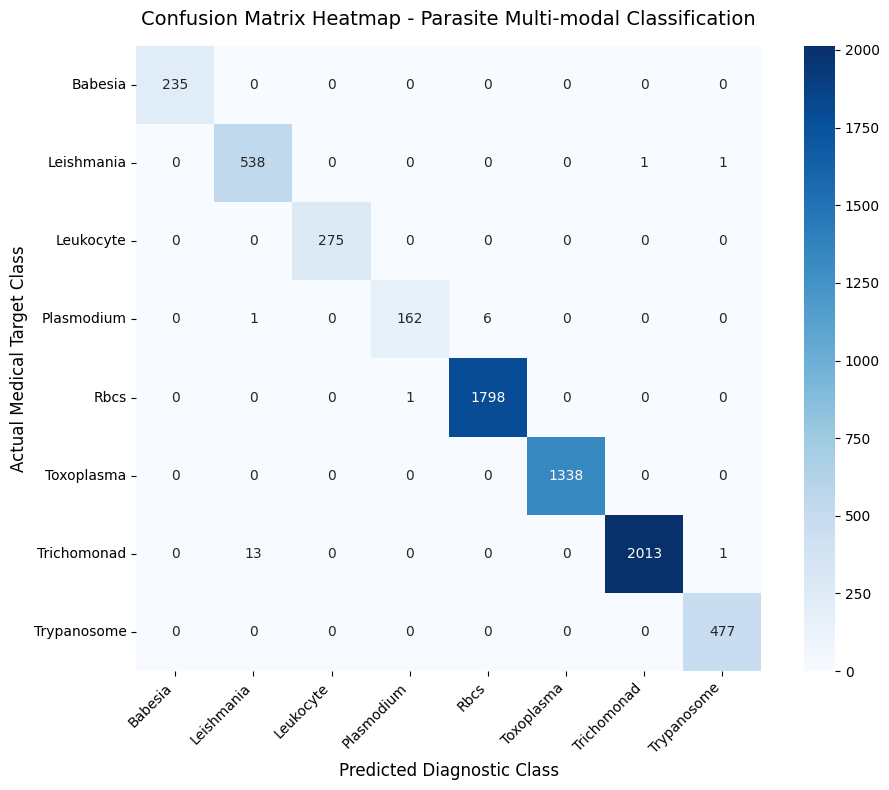

In [ ]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet34, ResNet34_Weights
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Environment and Path Configuration
from google.colab import drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

PROJECT_PATH = '/content/drive/MyDrive/Parasite_Project'
CSV_PATH = f"{PROJECT_PATH}/data/clinical_metadata.csv"
CHECKPOINT_PATH = f"{PROJECT_PATH}/checkpoints/best_multimodal_model.pth"

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"Metadata file not found at {CSV_PATH}. Please verify your step 2 path setup.")

# Re-create the Exact Test Dataset & Loader
df = pd.read_csv(CSV_PATH)
X_clinical = df[['temperature', 'hemoglobin', 'wbc_count', 'chills']].values
scaler = StandardScaler()
X_clinical_scaled = scaler.fit_transform(X_clinical)

# Re-split with identical random state (42) to keep the original test set stable
_, test_df, _, test_clin = train_test_split(
    df, X_clinical_scaled, test_size=0.2, random_state=42, stratify=df['label']
)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class MultimodalDataset(Dataset):
    def __init__(self, dataframe, clinical_data, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.clinical_data = clinical_data
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'image_path']
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.loc[idx, 'label'])
        clinical = torch.tensor(self.clinical_data[idx], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, clinical, label

test_dataset = MultimodalDataset(test_df, test_clin, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Define Multimodal Model Structure
class ParasiteMultimodalModel(nn.Module):
    def __init__(self, num_classes, clinical_dim):
        super().__init__()
        self.image_model = resnet34(weights=ResNet34_Weights.DEFAULT)
        img_features_dim = self.image_model.fc.in_features
        self.image_model.fc = nn.Identity()

        self.clinical_model = nn.Sequential(
            nn.Linear(clinical_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(img_features_dim + 32, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, image, clinical):
        img_feats = self.image_model(image)
        clin_feats = self.clinical_model(clinical)
        combined = torch.cat((img_feats, clin_feats), dim=1)
        logits = self.classifier(combined)
        return logits

num_classes = len(df['label'].unique())
class_names = sorted(df['label_name'].unique())

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
eval_model = ParasiteMultimodalModel(num_classes=num_classes, clinical_dim=4).to(device)

# Load Saved Weights from Google Drive
if os.path.exists(CHECKPOINT_PATH):
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    eval_model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Weights successfully restored from training epoch: {checkpoint['epoch']+1}")
else:
    raise FileNotFoundError(f"No checkpoint file found at {CHECKPOINT_PATH}")

# Execute Evaluation Pass
eval_model.eval()
all_preds = []
all_labels = []

print("Running batch inference on evaluation subset... Please hold...")
with torch.no_grad():
    for images, clinicals, labels in test_loader:
        images, clinicals = images.to(device), clinicals.to(device)

        outputs = eval_model(images, clinicals)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Generate Reports & Render Heatmap
print("\n" + "="*20 + " DETAILED CLASS REPORT " + "="*20)
print(classification_report(all_labels, all_preds, target_names=class_names))
print("="*63 + "\n")

# Compute structural confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Initialize and style Seaborn Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True,
    square=True
)

plt.title('Confusion Matrix Heatmap - Parasite Multi-modal Classification', fontsize=14, pad=15)
plt.ylabel('Actual Medical Target Class', fontsize=12)
plt.xlabel('Predicted Diagnostic Class', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Save image file to your project directory
HEATMAP_OUTPUT_PATH = f"{PROJECT_PATH}/checkpoints/confusion_matrix_heatmap.png"
plt.savefig(HEATMAP_OUTPUT_PATH, dpi=300)
print(f"Heatmap structural image copy securely saved at: {HEATMAP_OUTPUT_PATH}")

plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%%writefile app.py

import os
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.models import resnet34, ResNet34_Weights
from PIL import Image
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import streamlit as st

# Page Configuration & Custom Styling
st.set_page_config(
    page_title="Multimodal Parasite Diagnostic AI",
    page_icon="🔬",
    layout="wide"
)

st.title("🔬 Multimodal Parasite Diagnostic System")
st.markdown("---")

# Hardcoded Paths Configuration (Direct Google Drive Mount Paths)
# This avoids rerun of whole training pipeline since data is loaded dynamically
PROJECT_PATH = '/content/drive/MyDrive/Parasite_Project'
CSV_PATH = f"{PROJECT_PATH}/data/clinical_metadata.csv"
CHECKPOINT_PATH = f"{PROJECT_PATH}/checkpoints/best_multimodal_model.pth"

# Model Architecture Re-definition
class ParasiteMultimodalModel(nn.Module):
    def __init__(self, num_classes, clinical_dim):
        super().__init__()
        # Image Branch: Pre-trained ResNet34 with Identity FC layer for feature extraction
        self.image_model = resnet34(weights=ResNet34_Weights.DEFAULT)
        img_features_dim = self.image_model.fc.in_features
        self.image_model.fc = nn.Identity()

        # Clinical Branch: Multi-Layer Perceptron (MLP)
        self.clinical_model = nn.Sequential(
            nn.Linear(clinical_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # Late Fusion & Final Classification Head
        self.classifier = nn.Sequential(
            nn.Linear(img_features_dim + 32, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, image, clinical):
        img_feats = self.image_model(image)
        clin_feats = self.clinical_model(clinical)
        combined = torch.cat((img_feats, clin_feats), dim=1) # Modality Concatenation
        logits = self.classifier(combined)
        return logits

# Critical Dependencies Initialization & Caching
@st.cache_resource
def load_system_dependencies():
    """Loads CSV metadata, builds class mappings, initializes the scaler, and restores model checkpoint."""
    if not os.path.exists(CSV_PATH) or not os.path.exists(CHECKPOINT_PATH):
        st.error("Required artifacts missing! Ensure Google Drive is mounted correctly.")
        st.stop()

    # Read clinical baseline to align the input parameters
    df = pd.read_csv(CSV_PATH)
    num_classes = len(df['label'].unique())

    # Track the exact categorical indexing matching training script
    categories = df['label_name'].astype('category').cat.categories
    class_mapping = dict(enumerate(categories))

    # Initialize and fit standard scaler using baseline parameters
    X_clinical_baseline = df[['temperature', 'hemoglobin', 'wbc_count', 'chills']].values
    scaler = StandardScaler()
    scaler.fit(X_clinical_baseline)

    # Initialize the architecture on target device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = ParasiteMultimodalModel(num_classes=num_classes, clinical_dim=4).to(device)

    # Load frozen weights securely
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval() # Switch to evaluation mode for dropout stabilization

    return model, scaler, class_mapping, device

# Trigger dependency loader
model, scaler, class_mapping, device = load_system_dependencies()

# 5. User UI Layout Construction (Split Screen Design)
col1, col2 = st.columns([1, 1], gap="large")

with col1:
    st.subheader("📋 Patient Clinical Metadata & Vitals")

    # User Input Sliders & Selectboxes matching data structure
    temperature = st.slider("Body Temperature (°C)", 35.0, 42.0, 37.0, step=0.1, help="Normal range is ~36.5°C - 37.3°C")
    hemoglobin = st.slider("Hemoglobin Level (g/dL)", 5.0, 18.0, 13.0, step=0.1, help="Anemic levels fall below 11.0 g/dL")
    wbc_count = st.number_input("White Blood Cell Count (per μL)", min_value=1000, max_value=30000, value=7500, step=500)

    chills_input = st.selectbox("Experiencing Severe Chills / Shivering?", ["No", "Yes"])
    chills = 1 if chills_input == "Yes" else 0

with col2:
    st.subheader("🔬 Microscopic Blood Smear Image")

    # Medical file uploader segment
    uploaded_file = st.file_uploader("Upload Blood Smear Sample Image (.png, .jpg)", type=["png", "jpg", "jpeg"])

    if uploaded_file is not None:
        # Display uploaded artifact on screen
        st.image(uploaded_file, caption="Target Microscopic Specimen", width=350)

# Real-time Multimodal Prediction Pipeline
st.markdown("---")
if st.button("Run Multimodal Automated Diagnosis", use_container_width=True):
    if uploaded_file is None:
        st.warning("Prediction Halted: Please upload a cell microscopic image to execute fusion pipeline.")
    else:
        with st.spinner("Processing dual modalities and fusing feature spaces... Please wait..."):
            try:
                # Image Preprocessing Pipeline
                image_transform = transforms.Compose([
                    transforms.Resize((224, 224)),
                    transforms.ToTensor(),
                    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
                ])

                img = Image.open(uploaded_file).convert('RGB')
                img_tensor = image_transform(img).unsqueeze(0).to(device) # Expand dims for mini-batch context

                # Clinical Data Preprocessing (Normalization via pre-fitted baseline)
                raw_clinical = np.array([[temperature, hemoglobin, wbc_count, chills]])
                scaled_clinical = scaler.transform(raw_clinical)
                clinical_tensor = torch.tensor(scaled_clinical, dtype=torch.float32).to(device)

                # Inference Pass execution
                with torch.no_grad():
                    outputs = model(img_tensor, clinical_tensor)
                    probabilities = torch.softmax(outputs, dim=1)
                    confidence, predicted_class_idx = torch.max(probabilities, 1)

                # Decode prediction outputs
                predicted_label = class_mapping[predicted_class_idx.item()]
                confidence_percentage = confidence.item() * 100

                # Dynamic Diagnostic Report Layout
                st.success("🔬 Automated Diagnostic Analysis Complete!")

                res_col1, res_col2 = st.columns(2)
                with res_col1:
                    st.metric(label="Predicted Target Pathology", value=predicted_label)
                with res_col2:
                    st.metric(label="System Predictive Confidence", value=f"{confidence_percentage:.2f}%")

                # Enhanced conditional block optimized for validation
                if predicted_label != "Normal":
                    if confidence_percentage >= 40.0:
                        st.error(f"🔴 **Pathology Alert:** Positive biomarkers detected for **{predicted_label}** infection. Multimodal fusion pipeline confirms parasitic alignment.")
                    else:
                        st.warning(f"⚠️ **Weak Alignment Notification:** System leaning towards **{predicted_label}** but features are structurally distant from baseline training samples. Secondary manual slide screening suggested.")
                else:
                    st.success("🟢 **Normal Scan:** Patient biological metrics and micro-images fall within traditional baseline control limits.")

            except Exception as e:
                st.error(f"Execution Error occurred inside prediction core: {str(e)}")

Writing app.py


In [ ]:
import os

# Install Streamlit and Pyngrok safely using pip
!pip install streamlit pyngrok --quiet

from pyngrok import ngrok
ngrok.set_auth_token('3EYoDWd8Lws7GyNeEK1w2RuugXh_5b9FQ5U65w96KjqSDeE2C')

print("Ngrok environment and authtoken successfully configured! Your public IP is:")
!curl ipv4.icanhazip.com

Ngrok environment and authtoken successfully configured! Your public IP is:
8.231.231.132


In [ ]:
import os
!pip install streamlit pyngrok --quiet
from pyngrok import ngrok
ngrok.set_auth_token('3EYoDWd8Lws7GyNeEK1w2RuugXh_5b9FQ5U65w96KjqSDeE2C')

# Close any existing open tunnels just in case
ngrok.kill()

# Open a secure public HTTP tunnel on port 8501
public_url = ngrok.connect(8501, proto="http")
print(f"Your Streamlit App Live Link: {public_url}")
print("Opening tunnel background stream... Please hold...\n")

# 3. Boot up the Streamlit application in background
!streamlit run app.py --server.port 8501 --server.address 0.0.0.0

Your Streamlit App Live Link: NgrokTunnel: "https://rotting-handmade-scenic.ngrok-free.dev" -> "http://localhost:8501"
Opening tunnel background stream... Please hold...



2026-06-04 06:51:58.367 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://8.231.231.132:8501

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100% 83.3M/83.3M [00:00<00:00, 110MB/s]
